In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import sys
sys.path.append(str(Path('..').resolve()))
from config import DATA_PROCESSED, MODELS_DIR, FEATURE_COLS_PATH

from sklearn.metrics import f1_score
import xgboost

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print("Imports OK")
print(f"SHAP version: {shap.__version__}")

Imports OK
SHAP version: 0.45.0


In [2]:
# Load models
classifier  = joblib.load(MODELS_DIR / "classifier_best.pkl")
regressor   = joblib.load(MODELS_DIR / "regressor_best.pkl")
scaler      = joblib.load(MODELS_DIR / "scaler.pkl")

with open(FEATURE_COLS_PATH) as f:
    feature_columns = json.load(f)

with open(MODELS_DIR / "classifier_threshold.json") as f:
    thresh_data = json.load(f)

with open(MODELS_DIR / "regressor_meta.json") as f:
    reg_meta = json.load(f)

clf_threshold = thresh_data["threshold"]

# Load data
df = pd.read_csv(DATA_PROCESSED / "cloud_metrics_featured.csv")

# Recreate splits
n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

TARGET_CLF = 'is_anomaly'
TARGET_REG = 'cost_per_hour'

X     = df.drop(columns=[TARGET_CLF, TARGET_REG])
y_clf = df[TARGET_CLF]
y_reg = df[TARGET_REG]

reg_feature_columns = [c for c in feature_columns if c != TARGET_REG]
cost_idx            = feature_columns.index(TARGET_REG)

X_test     = X.iloc[val_end:][reg_feature_columns]
y_clf_test = y_clf.iloc[val_end:]
y_reg_test = y_reg.iloc[val_end:]

# Scale
X_test_full   = scaler.transform(
    X.iloc[val_end:].reindex(columns=feature_columns, fill_value=0))
X_test_scaled = np.delete(X_test_full, cost_idx, axis=1)

# Add anomaly proba for regressor
test_proba    = classifier.predict_proba(X_test_full)[:, 1]
X_test_stacked = np.column_stack([X_test_scaled, test_proba])

print(f"Classifier : {thresh_data['model']}")
print(f"Regressor  : {reg_meta['model']}")
print(f"Test rows  : {len(X_test):,}")
print(f"Clf features  : {X_test_full.shape[1]}")
print(f"Reg features  : {X_test_stacked.shape[1]}")

Classifier : XGBoost (threshold tuned)
Regressor  : XGBoost
Test rows  : 3,240
Clf features  : 95
Reg features  : 95


In [3]:
print("Building SHAP explainers (TreeExplainer — fast for XGBoost)...")

# Classifier SHAP — uses full 95 features
clf_explainer = shap.TreeExplainer(classifier)

# Regressor SHAP — uses 95 stacked features
reg_explainer = shap.TreeExplainer(regressor)

# Compute SHAP values on test set
# Use sample for speed (500 rows is enough for stable SHAP values)
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_full), size=500, replace=False)

X_clf_sample = X_test_full[sample_idx]
X_reg_sample = X_test_stacked[sample_idx]

print("Computing classifier SHAP values...")
clf_shap_values = clf_explainer.shap_values(X_clf_sample)

print("Computing regressor SHAP values...")
reg_shap_values = reg_explainer.shap_values(X_reg_sample)

# Feature names
clf_feature_names = feature_columns
reg_feature_names = reg_feature_columns + ["anomaly_probability"]

print(f"\nClassifier SHAP shape : {np.array(clf_shap_values).shape}")
print(f"Regressor SHAP shape  : {np.array(reg_shap_values).shape}")
print("SHAP computation complete!")

Building SHAP explainers (TreeExplainer — fast for XGBoost)...
Computing classifier SHAP values...
Computing regressor SHAP values...

Classifier SHAP shape : (500, 95)
Regressor SHAP shape  : (500, 95)
SHAP computation complete!


Plotting classifier SHAP beeswarm...


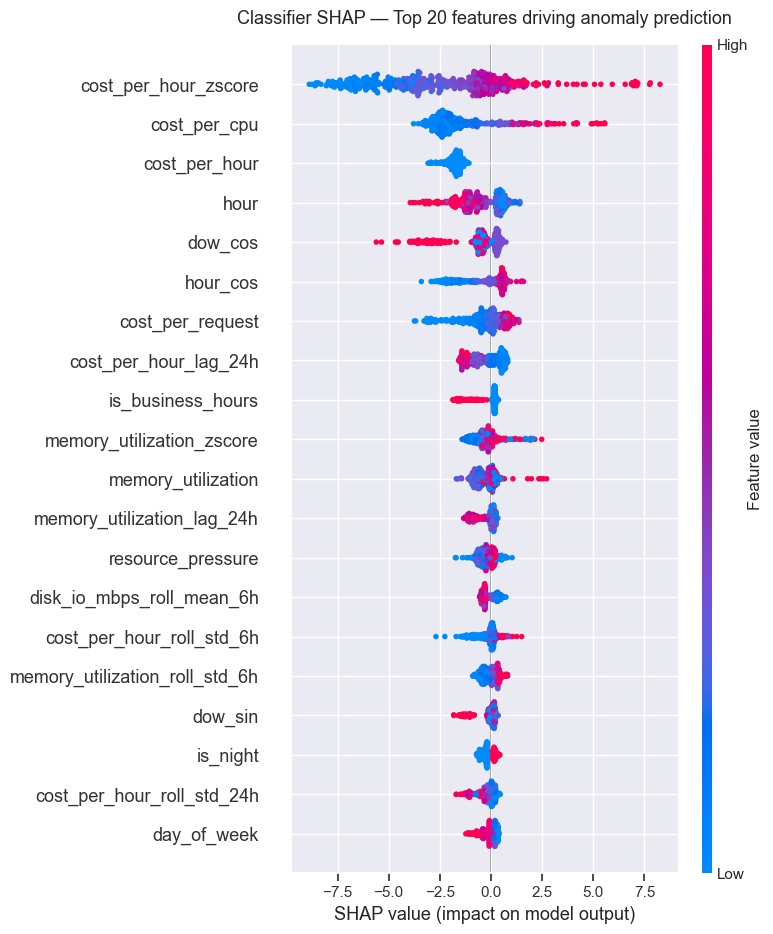

Saved: shap_classifier_beeswarm.png


In [4]:
print("Plotting classifier SHAP beeswarm...")

# For binary XGBoost, shap_values may be 3D — handle both cases
if isinstance(clf_shap_values, list):
    clf_sv = clf_shap_values[1]   # class 1 = anomaly
elif len(np.array(clf_shap_values).shape) == 3:
    clf_sv = clf_shap_values[:, :, 1]
else:
    clf_sv = clf_shap_values

shap.summary_plot(
    clf_sv,
    X_clf_sample,
    feature_names=clf_feature_names,
    max_display=20,
    show=False,
    plot_type="dot"
)
plt.title("Classifier SHAP — Top 20 features driving anomaly prediction",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_classifier_beeswarm.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_classifier_beeswarm.png")

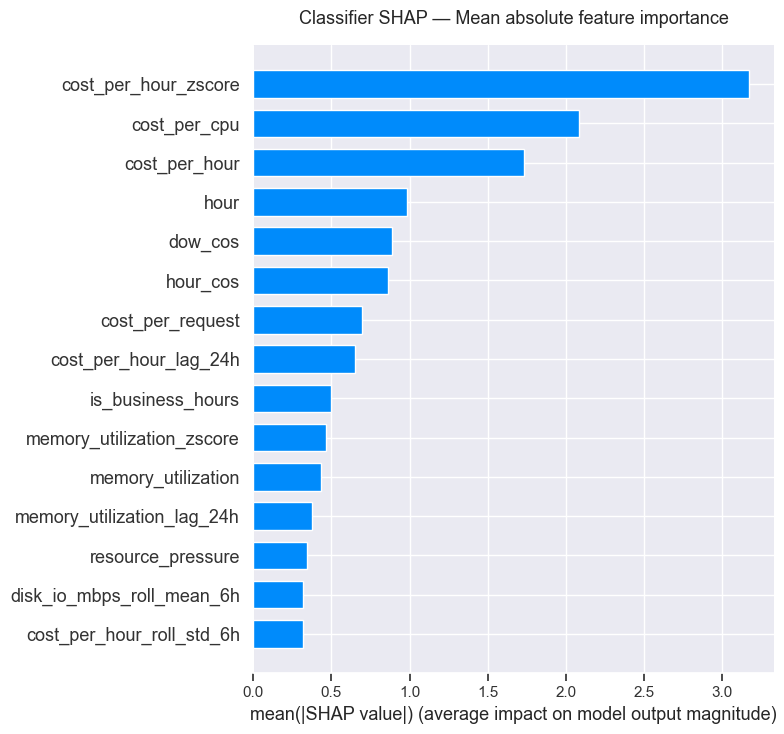

In [5]:
shap.summary_plot(
    clf_sv,
    X_clf_sample,
    feature_names=clf_feature_names,
    max_display=15,
    show=False,
    plot_type="bar"
)
plt.title("Classifier SHAP — Mean absolute feature importance",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_classifier_bar.png",
            dpi=150, bbox_inches='tight')
plt.show()

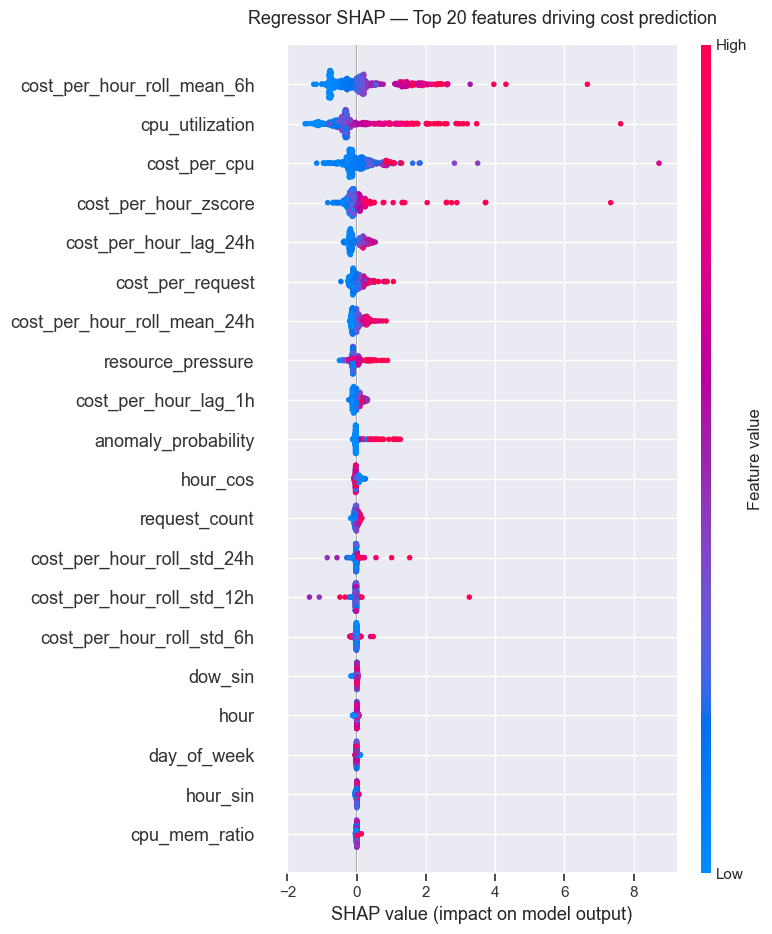

Saved: shap_regressor_beeswarm.png


In [6]:
# Handle regressor SHAP shape
if isinstance(reg_shap_values, list):
    reg_sv = reg_shap_values[0]
elif len(np.array(reg_shap_values).shape) == 3:
    reg_sv = reg_shap_values[:, :, 0]
else:
    reg_sv = reg_shap_values

shap.summary_plot(
    reg_sv,
    X_reg_sample,
    feature_names=reg_feature_names,
    max_display=20,
    show=False,
    plot_type="dot"
)
plt.title("Regressor SHAP — Top 20 features driving cost prediction",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_regressor_beeswarm.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_regressor_beeswarm.png")

Correctly predicted anomalies in test: 202
Explaining test row index: 828
Anomaly probability      : 1.0000
Actual label             : 1


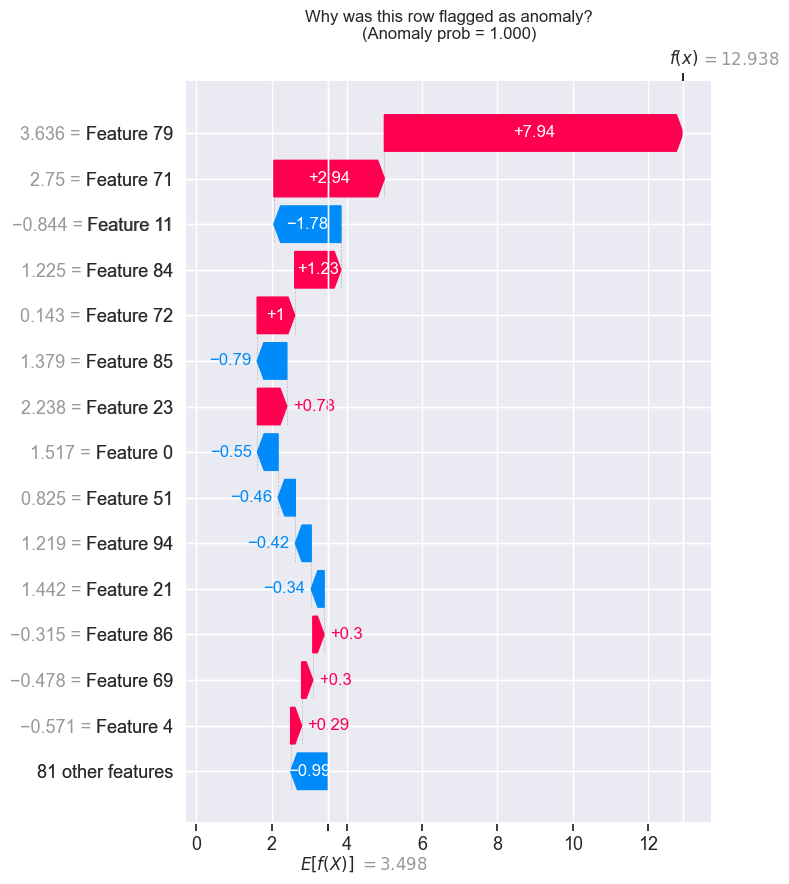

Saved: shap_waterfall_classifier.png


In [7]:
# Find a clear anomaly in test set to explain
y_test_pred_proba = classifier.predict_proba(X_test_full)[:, 1]
anomaly_indices   = np.where(
    (y_clf_test.values == 1) & (y_test_pred_proba >= clf_threshold)
)[0]

print(f"Correctly predicted anomalies in test: {len(anomaly_indices)}")

# Pick the most confident anomaly prediction
most_confident_idx = anomaly_indices[
    np.argmax(y_test_pred_proba[anomaly_indices])
]

print(f"Explaining test row index: {most_confident_idx}")
print(f"Anomaly probability      : {y_test_pred_proba[most_confident_idx]:.4f}")
print(f"Actual label             : {y_clf_test.values[most_confident_idx]}")

# SHAP waterfall for this single prediction
single_clf_shap = clf_explainer(X_test_full[most_confident_idx:most_confident_idx+1])

# Handle shape
if len(single_clf_shap.shape) == 3:
    explanation = single_clf_shap[:, :, 1]
else:
    explanation = single_clf_shap

shap.waterfall_plot(explanation[0], max_display=15, show=False)
plt.title(f"Why was this row flagged as anomaly?\n"
          f"(Anomaly prob = {y_test_pred_proba[most_confident_idx]:.3f})",
          fontsize=12)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_waterfall_classifier.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall_classifier.png")

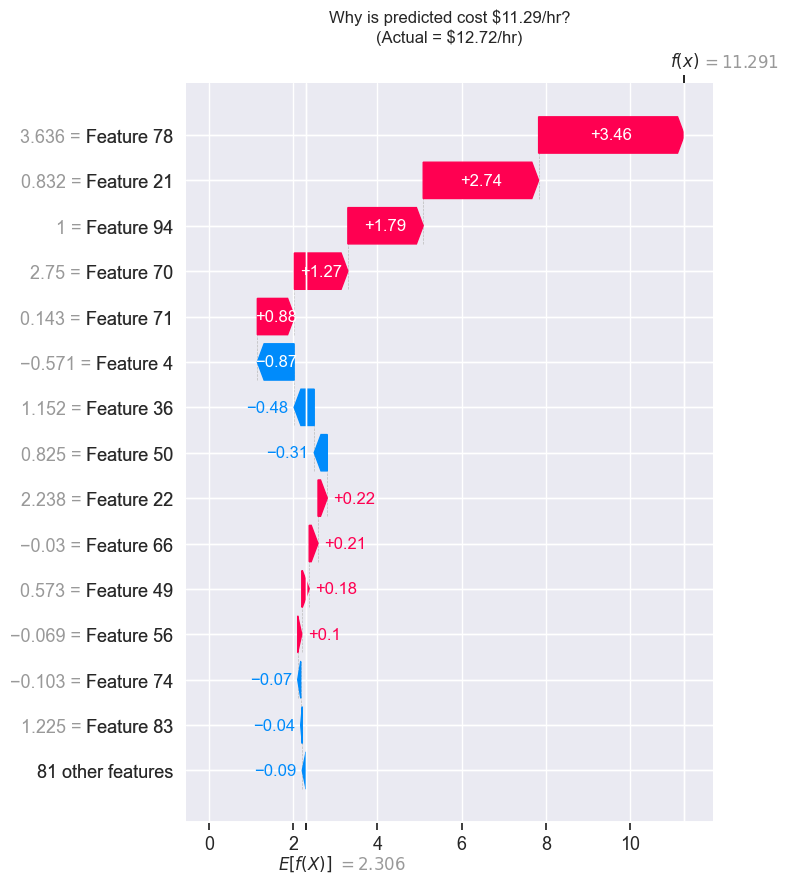

Saved: shap_waterfall_regressor.png


In [8]:
# Explain cost prediction for same anomalous row
single_reg_shap = reg_explainer(
    X_test_stacked[most_confident_idx:most_confident_idx+1])

if len(single_reg_shap.shape) == 3:
    reg_explanation = single_reg_shap[:, :, 0]
else:
    reg_explanation = single_reg_shap

predicted_cost = regressor.predict(
    X_test_stacked[most_confident_idx:most_confident_idx+1])[0]
actual_cost    = y_reg_test.values[most_confident_idx]

shap.waterfall_plot(reg_explanation[0], max_display=15, show=False)
plt.title(f"Why is predicted cost ${predicted_cost:.2f}/hr?\n"
          f"(Actual = ${actual_cost:.2f}/hr)",
          fontsize=12)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_waterfall_regressor.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall_regressor.png")

Top classifier feature: cost_per_hour_zscore


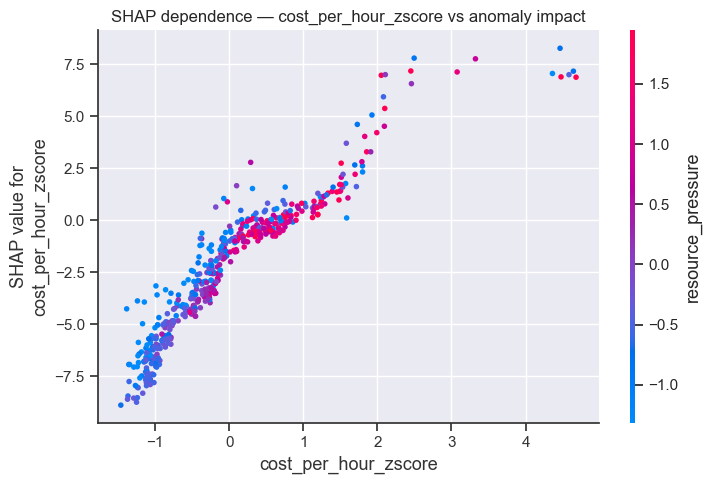

Saved: shap_dependence_cost_per_hour_zscore.png


In [10]:
# Dependence plot shows how the top feature interacts with predictions
# Pick top feature from classifier

mean_abs_shap   = np.abs(clf_sv).mean(axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature     = clf_feature_names[top_feature_idx]

print(f"Top classifier feature: {top_feature}")

shap.dependence_plot(
    top_feature_idx,
    clf_sv,
    X_clf_sample,
    feature_names=clf_feature_names,
    show=False
)
plt.title(f"SHAP dependence — {top_feature} vs anomaly impact",
          fontsize=12)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_dependence_top_feature.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: shap_dependence_{top_feature}.png")

In [11]:
# Top 10 features for both models — clean summary
clf_importance = pd.DataFrame({
    'feature' : clf_feature_names,
    'mean_shap': np.abs(clf_sv).mean(axis=0)
}).sort_values('mean_shap', ascending=False).head(10)

reg_importance = pd.DataFrame({
    'feature'  : reg_feature_names,
    'mean_shap': np.abs(reg_sv).mean(axis=0)
}).sort_values('mean_shap', ascending=False).head(10)

print("=" * 50)
print("TOP 10 FEATURES — CLASSIFIER")
print("=" * 50)
print(clf_importance.to_string(index=False))

print("\n" + "=" * 50)
print("TOP 10 FEATURES — REGRESSOR")
print("=" * 50)
print(reg_importance.to_string(index=False))

print(f"\nSHAP plots saved to: {MODELS_DIR}")
print("\nNext → 07_pipeline_integration.ipynb")

TOP 10 FEATURES — CLASSIFIER
                  feature  mean_shap
     cost_per_hour_zscore   3.171647
             cost_per_cpu   2.084208
            cost_per_hour   1.731526
                     hour   0.983559
                  dow_cos   0.889608
                 hour_cos   0.863420
         cost_per_request   0.695132
    cost_per_hour_lag_24h   0.650474
        is_business_hours   0.497321
memory_utilization_zscore   0.462415

TOP 10 FEATURES — REGRESSOR
                    feature  mean_shap
 cost_per_hour_roll_mean_6h   0.649318
            cpu_utilization   0.615518
               cost_per_cpu   0.339927
       cost_per_hour_zscore   0.231763
      cost_per_hour_lag_24h   0.191273
           cost_per_request   0.140871
cost_per_hour_roll_mean_24h   0.128525
          resource_pressure   0.124494
       cost_per_hour_lag_1h   0.088974
        anomaly_probability   0.076085

SHAP plots saved to: D:\B.TECH\Projects\cloud-anomaly-detector\models

Next → 07_pipeline_integration.ipy